In [1]:
!pip install imutils

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os 
from imutils import paths

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
dataset = "dataset"

In [3]:
imagePaths=list(paths.list_images(dataset))

In [4]:
imagePaths

['dataset/with_mask/63.jpg',
 'dataset/with_mask/1_0_2 copy 6.jpg',
 'dataset/with_mask/0_0_24 copy.jpg',
 'dataset/with_mask/with_mask439.jpg',
 'dataset/with_mask/189.jpg',
 'dataset/with_mask/0_0_8 copy 10.jpg',
 'dataset/with_mask/0_0_25 copy.jpg',
 'dataset/with_mask/77.jpg',
 'dataset/with_mask/with_mask405.jpg',
 'dataset/with_mask/with_mask363.jpg',
 'dataset/with_mask/Screenshot (364).png',
 'dataset/with_mask/download (1).png',
 'dataset/with_mask/with_mask377.jpg',
 'dataset/with_mask/with_mask411.jpg',
 'dataset/with_mask/with_mask388.jpg',
 'dataset/with_mask/0_0_34.jpg',
 'dataset/with_mask/with_mask645.jpeg',
 'dataset/with_mask/1_0_20.jpg',
 'dataset/with_mask/162.jpg',
 'dataset/with_mask/176.jpg',
 'dataset/with_mask/0_0_7 copy 7.jpg',
 'dataset/with_mask/with_mask161.png',
 'dataset/with_mask/0_0_20.jpg',
 'dataset/with_mask/88.jpg',
 'dataset/with_mask/1_0_8.jpg',
 'dataset/with_mask/0_0_6 copy 23.jpg',
 'dataset/with_mask/with_mask149.jpg',
 'dataset/with_mask/0_0_

In [5]:
data=[]
labels=[]

for i in imagePaths:
    label=i.split(os.path.sep)[-2]
    labels.append(label)
    image = load_img(i,target_size=(96,96))
    image = img_to_array(image)
    image = preprocess_input(image)
    data.append(image)

/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [6]:
data = np.array(data,dtype='float32')
labels = np.array(labels)

In [7]:
labels

array(['with_mask', 'with_mask', 'with_mask', ..., 'without_mask',
       'without_mask', 'without_mask'], dtype='<U12')

In [8]:
lb=LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)

In [9]:
labels

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [10]:
## Splitting of Data

train_X,test_X,train_Y,test_Y = train_test_split(data,labels,test_size=0.20,random_state=10,stratify=labels)

In [11]:
train_X

array([[[[ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ]],

        [[ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ]],

        [[ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         ...,
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 1.        ,  1.        ,  1.        ]],

        ...,

        [[-0.81960785, -0.8666667 , -0

In [12]:
train_Y.size

6546

In [13]:
test_Y.size

1638

In [14]:
aug=ImageDataGenerator(
                       rotation_range=20,
                       zoom_range=0.15,width_shift_range=0.2,
                       height_shift_range=0.2,shear_range=0.15,
                       horizontal_flip=True,
                       vertical_flip=True,
                       fill_mode='nearest'
                       )

In [15]:
input_shape = (96,96,3)

In [18]:
baseModel = MobileNetV2(weights="imagenet", include_top=False,
                        input_tensor=Input(shape=(96, 96, 3)))

# Freeze base model layers
baseModel.trainable = False

# Add custom head
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(3, 3))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

# Combine
model = Model(inputs=baseModel.input, outputs=headModel)

/var/folders/8w/yykv550j5sg6mjylzh6wk80m0000gn/T/ipykernel_48009/1947364437.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False,


In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
lr=0.0005
Epochs=100
BS=32

opt=Adam(learning_rate=lr,decay=lr/Epochs)

/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [21]:
model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])

In [22]:
history=model.fit(
aug.flow(train_X,train_Y,batch_size=BS),
steps_per_epoch=len(train_X)//BS,
validation_data=(test_X,test_Y),
validation_steps=len(test_X)//BS,
epochs=Epochs
    
)


Epoch 1/100


/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_154']
Received: inputs=Tensor(shape=(None, 96, 96, 3))
  warnings.warn(msg)


102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.8055 - loss: 0.5381 - val_accuracy: 0.9756 - val_loss: 0.0789
Epoch 2/100
  1/102 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9375 - loss: 0.1217

/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9375 - loss: 0.1217 - val_accuracy: 0.9768 - val_loss: 0.0789
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9442 - loss: 0.1723 - val_accuracy: 0.9756 - val_loss: 0.0597
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9062 - loss: 0.2464 - val_accuracy: 0.9756 - val_loss: 0.0596
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9459 - loss: 0.1749 - val_accuracy: 0.9792 - val_loss: 0.0547
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9688 - loss: 0.1331 - val_accuracy: 0.9780 - val_loss: 0.0533
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9497 - loss: 0.1319 - val_accuracy: 0.9756 - val_loss: 0.0635
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9375 - loss: 0.1775 - val_accuracy: 0.9768 - val_loss: 0.0628
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9490 - loss: 0.1454 - val_accuracy

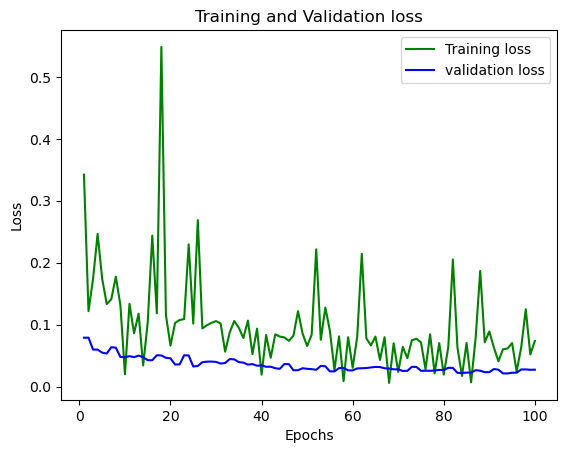

In [23]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,101)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

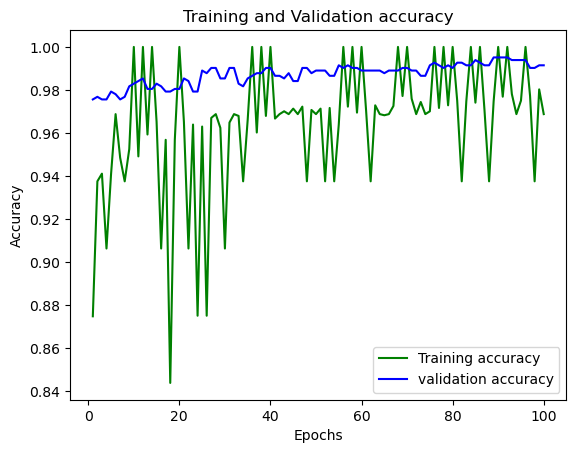

In [24]:
acc_train = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1,101)
plt.plot(epochs, acc_train, 'g', label='Training accuracy')
plt.plot(epochs, acc_val, 'b', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

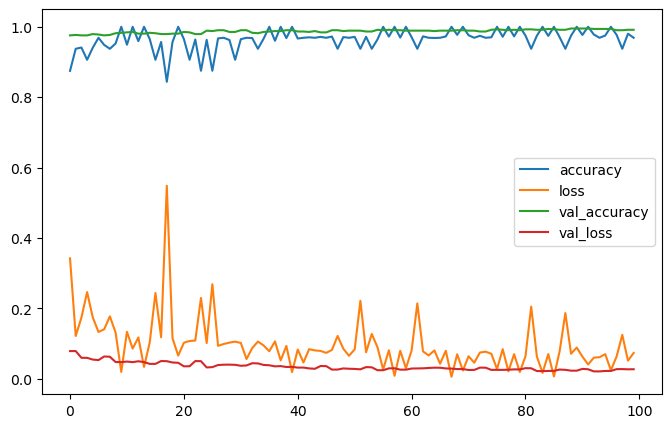

In [25]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [26]:
model.save('mobilenetv2_4300_32_100.keras')

In [27]:
predict=model.predict(test_X,batch_size=BS)
predict=np.argmax(predict,axis=1)
print(classification_report(test_Y.argmax(axis=1),predict,target_names=lb.classes_))

/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_154']
Received: inputs=Tensor(shape=(32, 96, 96, 3))
  warnings.warn(msg)


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

/Users/bhaveshduttmyla/Desktop/sample_project/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_154']
Received: inputs=Tensor(shape=(None, 96, 96, 3))
  warnings.warn(msg)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       433
without_mask       0.99      0.99      0.99       386

    accuracy                           0.99       819
   macro avg       0.99      0.99      0.99       819
weighted avg       0.99      0.99      0.99       819

